# Chapter 18: When an Action Has Coordinates

A release button moves after the controller observes the page. The old coordinates now point to delete. The controller can still issue a perfectly formed click, but the effect boundary has changed. The mistake is not explained by text prediction alone; it belongs to observation age, layout state, and action targeting.

This notebook represents three interfaces. Coordinate action uses the current object at an old location. Semantic action uses the resolved object identifier. Version-bound action also checks that the observed and current layouts match. All three still require freshness and current permission. The experiment distinguishes issuing an action, hitting the intended target, and confirming completion.

**Outcome:** Compare coordinate, semantic, and version-bound action contracts.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let age be observation age and tau the maximum permitted age. Freshness is F=1{age<=tau}. Current authorization is A. Target correctness is T=1{resolved target=wanted target}. Version validity is V=1{observed version=current version} for the version-bound interface.

For coordinate and semantic methods, issuance is F and A under this simplified contract. For version-bound action it is F and A and V. Authorized confirmed completion additionally requires target correctness and an effect-confirmation flag. Those predicates represent different evidence: an issued request can be wrong, and a correct target can still lack confirmation.

The coordinate method deliberately has no semantic identity check before issuance. The semantic method avoids the particular moved-location failure but can still resolve the wrong object. Version binding rejects a changed layout rather than guessing whether the old observation remains sufficient. Age and version are separate: a recent observation can already be obsolete, and an old observation may describe an unchanged layout.

## A calculation you can run

Supply age, freshness limit, observed and current versions, current permission, effect confirmation, and target identifiers. Exact boolean checks keep authorization and confirmation distinct from truthy strings. The function emits one row per interface with freshness, version match, authorization, issuance, target correctness, and confirmed completion.

Two figures compare issued actions and confirmed completions. Their difference is operationally important; a higher issuance bar does not imply better behavior. Run the default layout-change case, then increase only observation age beyond the limit. Predict which interfaces will refuse issuance. The transfer case removes permission while preserving fresh, matching observations, checking that a stable interface cannot manufacture authority.

For a visual version of the stale-coordinate example, open the [release console](../Companion/release-console.html) in a browser. It is a local mock-up whose effects stay inside the page.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 18
inputs = {'observation_age': 1,
 'max_age': 2,
 'observed_version': 'layout-1',
 'current_version': 'layout-2',
 'current_permission': True,
 'effect_confirmed': True,
 'coordinate_target': 'delete',
 'semantic_target': 'release',
 'wanted_target': 'release',
 'change_rate': 0.02,
 'delays': [5, 15, 30]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 18: interface-freshness
Does an observed interface still support an authorized action at the intended target?
Evidence: constructed teaching example

Calculated quantities:
{
  "methods": [
    {
      "method": "coordinate",
      "fresh": true,
      "version_matches": true,
      "authorized": true,
      "issued": true,
      "correct_target": false,
      "confirmed_completion": false
    },
    {
      "method": "semantic",
      "fresh": true,
      "version_matches": true,
      "authorized": true,
      "issued": true,
      "correct_target": true,
      "confirmed_completion": true
    },
    {
      "method": "version-bound",
      "fresh": true,
      "version_matches": false,
      "authorized": true,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    }
  ],
  "stale_observation": false,
  "layout_changed": true,
  "change_rate": 0.02,
  "freshness_probability_at_age": 0.9801986733,
  "freshness_probability_at_max_age": 0.9

The default coordinate action is issued at a fresh observation age but points to delete, so confirmed completion is false. Semantic targeting points to release and is issued, giving confirmed completion true under the supplied receipt flag. Version-bound action refuses issuance because layout-1 differs from layout-2.

In the changed case age 3 exceeds max_age 2. All interfaces refuse issuance, including the semantic one. Freshness policy changes the action set before any claim of completion. The result does not say the page was unusable; it says this declared contract requires a renewed observation before acting.

Equation 18.3 is also computed when change_rate is supplied. With rate 0.02 changes per second, delays of 5, 15 and 30 seconds give freshness probabilities 0.9048, 0.7408 and 0.5488, which reproduces the chapter's second exercise. This is a constant-rate model of how likely no invalidating change has occurred. It is reported beside the age-limit rule, not in place of it, and a bursty update pattern would make it unsuitable.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


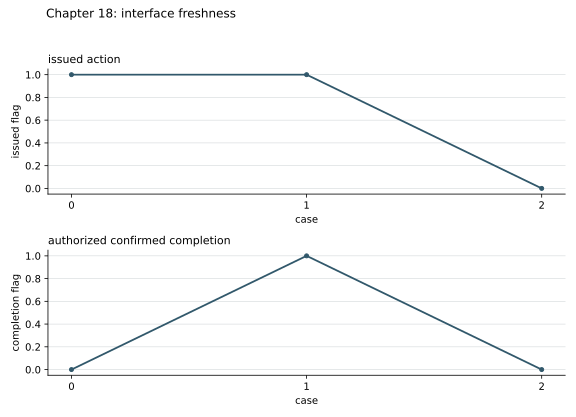

In [3]:
display(SVG(figure_svg(report)))

**Figure 18.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Semantic targeting is not a universal repair for computer-use errors. Labels can be duplicated, accessibility trees can be stale, and resolver rules can name the wrong object. The runtime accepts a declared semantic target so that this boundary stays visible rather than assuming semantics equals correctness.

A second failure treats historical permission as current authority. The controller must check permission at issuance, not merely remember that a similar action was allowed earlier. The transfer case blocks every method despite correct targets and matching versions.

Finally, a click receipt is not necessarily an effect receipt. This experiment's confirmation flag refers to the desired completed effect. Real interfaces may need a state query, durable operation identifier, or verification page. Do not translate a low-level input event into terminal completion without that evidence.

Chapter 18: interface-freshness
Does an observed interface still support an authorized action at the intended target?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "methods": [
    {
      "method": "coordinate",
      "fresh": false,
      "version_matches": true,
      "authorized": true,
      "issued": false,
      "correct_target": false,
      "confirmed_completion": false
    },
    {
      "method": "semantic",
      "fresh": false,
      "version_matches": true,
      "authorized": true,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "version-bound",
      "fresh": false,
      "version_matches": false,
      "authorized": true,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    }
  ],
  "stale_observation": true,
  "layout_changed": true,
  "change_rate": 0.02,
  "freshness_probability_at_age": 0.9417645336,
  "freshness_probability_a

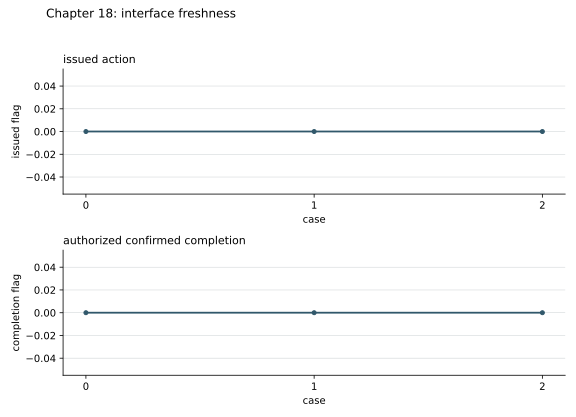

In [4]:
changed_inputs = {'observation_age': 3,
 'max_age': 2,
 'observed_version': 'layout-1',
 'current_version': 'layout-2',
 'current_permission': True,
 'effect_confirmed': True,
 'coordinate_target': 'delete',
 'semantic_target': 'release',
 'wanted_target': 'release',
 'change_rate': 0.02,
 'delays': [5, 15, 30]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 18.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer observation is fresh, versions match, and both target methods resolve submit correctly. Current permission is false, so every issuance flag is false. This is an authority boundary independent of perception accuracy.

For local use, preserve the observed target, action-time target, layout version, and timestamp. If a field is unavailable, specify the observation needed instead of guessing it. Compare interfaces under the same task and permission contract. Use uncertain-effect tracing after issuance when the real question is whether the remote action happened despite a missing acknowledgement.

In [5]:
transfer_inputs = {'observation_age': 0,
 'max_age': 1,
 'observed_version': 'page-C',
 'current_version': 'page-C',
 'current_permission': False,
 'effect_confirmed': False,
 'coordinate_target': 'submit',
 'semantic_target': 'submit',
 'wanted_target': 'submit',
 'change_rate': 0.05,
 'delays': [2, 10]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 18: interface-freshness
Does an observed interface still support an authorized action at the intended target?
Evidence: constructed transfer example

Calculated quantities:
{
  "methods": [
    {
      "method": "coordinate",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "semantic",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "version-bound",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    }
  ],
  "stale_observation": false,
  "layout_changed": false,
  "change_rate": 0.05,
  "freshness_probability_at_age": 1.0,
  "freshness_probability_at_max_age": 0.95122

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **observation_age:** Nonnegative elapsed time since observation.
- **max_age:** Nonnegative freshness limit in the same time unit.
- **observed_version:** Version seen in the observation.
- **current_version:** Version at action time.
- **current_permission:** Exact boolean current authorization.
- **effect_confirmed:** Exact boolean receipt of desired effect confirmation.
- **coordinate_target:** Current object located at previously observed coordinates.
- **semantic_target:** Current object resolved by semantic interface.
- **wanted_target:** Intended object identifier.
- **change_rate:** Optional nonnegative rate of invalidating interface changes per unit time. When given, Fresh(delay)=exp(-rate*delay) from Equation 18.3 is reported.
- **delays:** Optional list of nonnegative delays in the same time unit; requires change_rate.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch18.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 18: interface-freshness
Does an observed interface still support an authorized action at the intended target?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "methods": [
    {
      "method": "coordinate",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "semantic",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    },
    {
      "method": "version-bound",
      "fresh": true,
      "version_matches": true,
      "authorized": false,
      "issued": false,
      "correct_target": true,
      "confirmed_completion": false
    }
  ],
  "stale_observation": false,
  "layout_changed": false,
  "change_rate": 0.05,
  "freshness_probability_at_age": 1.0,
  "freshness_

## Questions

1. Why does default coordinate completion fail?

2. Can matching versions replace current permission?

3. What does observation age 3 do under max_age = 2?

4. With change_rate 0.02 per second, compute the no-invalidating-change probability for delays of 5, 15 and 30 seconds.

Answers: [separate solutions](../solutions/ch18.md). Try the calculation before opening them.

## Summary

Actions with coordinates depend on a changing interface. Freshness, version binding, current permission, target correctness, and effect confirmation are separate predicates. The moved-layout example exposes a coordinate failure; the stale-observation case blocks issuance; the transfer case blocks action for missing authority. Semantic targeting helps only within its resolver contract. The calculation reports declared interface behavior without claiming that any live page was observed or controlled.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-18-interface-freshness`](../skills/maa-18-interface-freshness/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 18.1

![Equation 18.1](../assets/math/755fe6a5928a4b2e29ce.svg)

Equation (18.1) composes an interface's execution law with the world transitions caused by its realized operations.

For each operation the command might realize in the current state, multiply its execution probability by its next-state law, then add those possibilities.

LaTeX source, preserved for inspection:

```latex
P_{\mathrm{ui}}(x'\mid x,a)
=
\sum_{\tilde a\in\operatorname{Act}_{\mathrm{ui}}}
\operatorname{Exec}_{\mathrm{ui}}(\tilde a\mid x,a)
P(x'\mid x,\tilde a).
\tag{18.1}
```

### Equation 18.2

![Equation 18.2](../assets/math/4b0b524edbcf02f6262f.svg)

Equation (18.2) retains actions authorized in every state still considered possible.

An action survives only if each state with positive belief weight permits it.

LaTeX source, preserved for inspection:

```latex
\mathcal A_{\mathrm{rob}}(\mathbf b)
=
\bigcap_{x:\,\mathbf b(x)>0}\mathcal A_{\mathrm{auth}}(x).
\tag{18.2}
```

### Equation 18.3

![Equation 18.3](../assets/math/2f33e21b021d2dab73fc.svg)

Equation (18.3) gives the chance that a coordinate binding remains valid over a delay in the stated constant-rate construction.

Longer delay and a higher material-change rate both lower the chance that no invalidating change has occurred.

LaTeX source, preserved for inspection:

```latex
\operatorname{Fresh}(\Delta)
=
\exp(-\lambda_{\mathrm{ui}}\Delta).
\tag{18.3}
```